<a href="https://colab.research.google.com/github/shreenyshadham/Mars-Rover/blob/main/notebooks/01_interim_prototype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running PyBaMM lithium-ion battery discharge simulation...


,time_min,cell_voltage_v,discharge_capacity_ah,estimated_soc_percent
0,0.000000,3.780081,0.000000,100.000000
1,0.000202,3.780066,0.000002,99.999675
2,0.000403,3.780051,0.000005,99.999350
3,0.000806,3.780021,0.000009,99.998701
4,0.001612,3.779963,0.000018,99.997401


Voltage lookup check:
Cell voltage at 100% SoC: 3.78 V
Cell voltage at 50% SoC: 3.635 V
Cell voltage at 0% SoC: 2.5 V

Scenario power demands:
flat_drive: 50.0 W
rocky_drive: 67.2 W
sand_slope_drive: 93.2 W
science_task: 70.0 W

Mission telemetry created.
Mission dataframe shape: (75, 12)

Risk label counts:
risk_label
critical    40
safe        27
warning      8
Name: count, dtype: int64


,time_min,scenario,temperature_c,capacity_factor,effective_capacity_wh,power_w,energy_used_wh,soc_percent,pack_voltage_v,current_a,risk_label,soc_future_10
0,0,flat_drive,-50.000000,0.7,42.0,50.0,0.833333,98.015873,11.292113,4.427869,safe,78.174603
1,1,flat_drive,-49.872293,0.7,42.0,50.0,0.833333,96.031746,11.264201,4.438841,safe,76.190476
2,2,flat_drive,-49.744589,0.7,42.0,50.0,0.833333,94.047619,11.238865,4.448848,safe,74.206349
3,3,flat_drive,-49.616889,0.7,42.0,50.0,0.833333,92.063492,11.215070,4.458287,safe,72.222222
4,4,flat_drive,-49.489197,0.7,42.0,50.0,0.833333,90.079365,11.192580,4.467245,safe,70.238095



Table 1: Prototype dataset and configuration summary


,Item,Value
0,Battery chemistry,Li-ion
1,Nominal voltage,12 V
2,Battery capacity,5 Ah / 60 Wh
3,Forecast horizon,10 minutes
4,Warning threshold,40% SoC
5,Critical threshold,20% SoC
6,Telemetry interval,1 minute
7,Usable rows,75
8,Number of variables,12



Table 2: Scenario-level energy demand summary


,Scenario,Mean Power (W),Mean Current (A),Mean Voltage (V),Final SoC (%),Samples
0,Flat Drive,50.0,4.50,11.11,60.32,20
1,Rocky Drive,67.2,6.27,10.73,6.98,20
2,Sand Slope Drive,93.2,12.36,7.54,0.00,25
3,Science Task,70.0,9.33,7.50,0.00,10



Table 3: Preliminary model comparison


,Model,MAE,RMSE,R2,Status
0,Linear Regression,1.288,1.627,0.997,Prototype tested
1,Random Forest,0.464,0.908,0.999,Prototype tested
2,LSTM,0.027,0.027,0.000,Initial trial


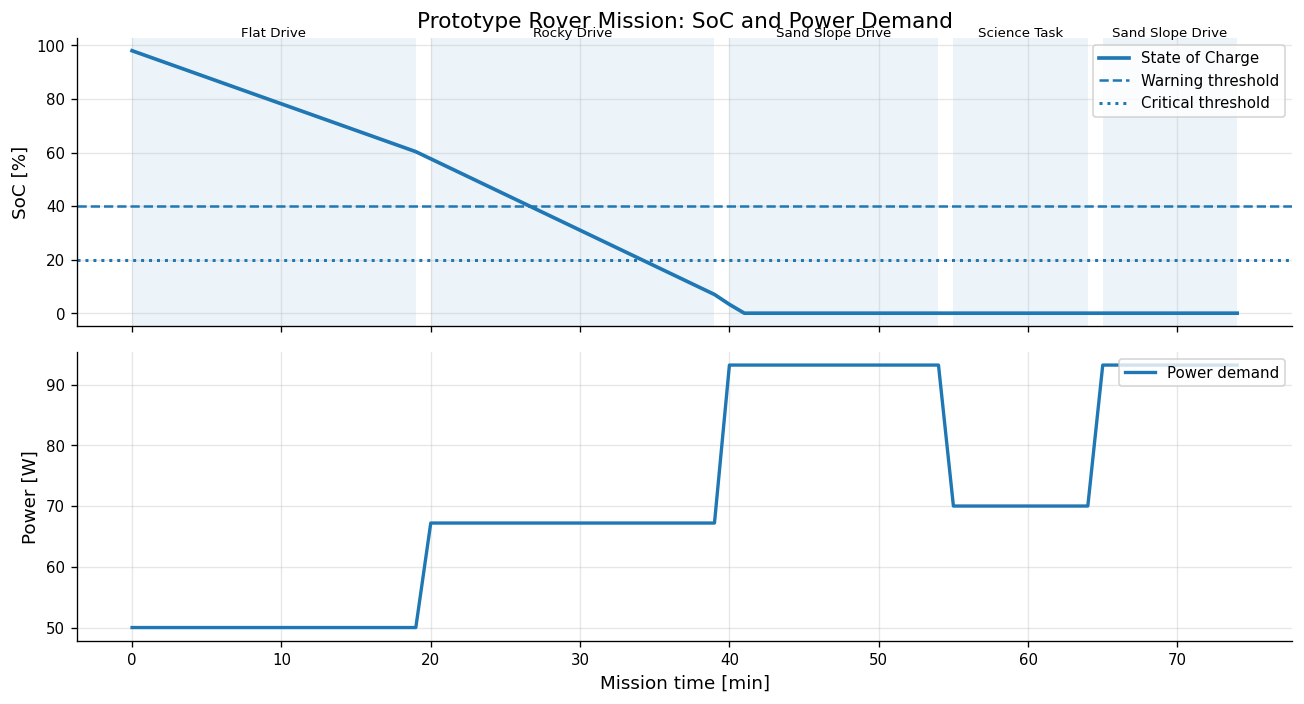

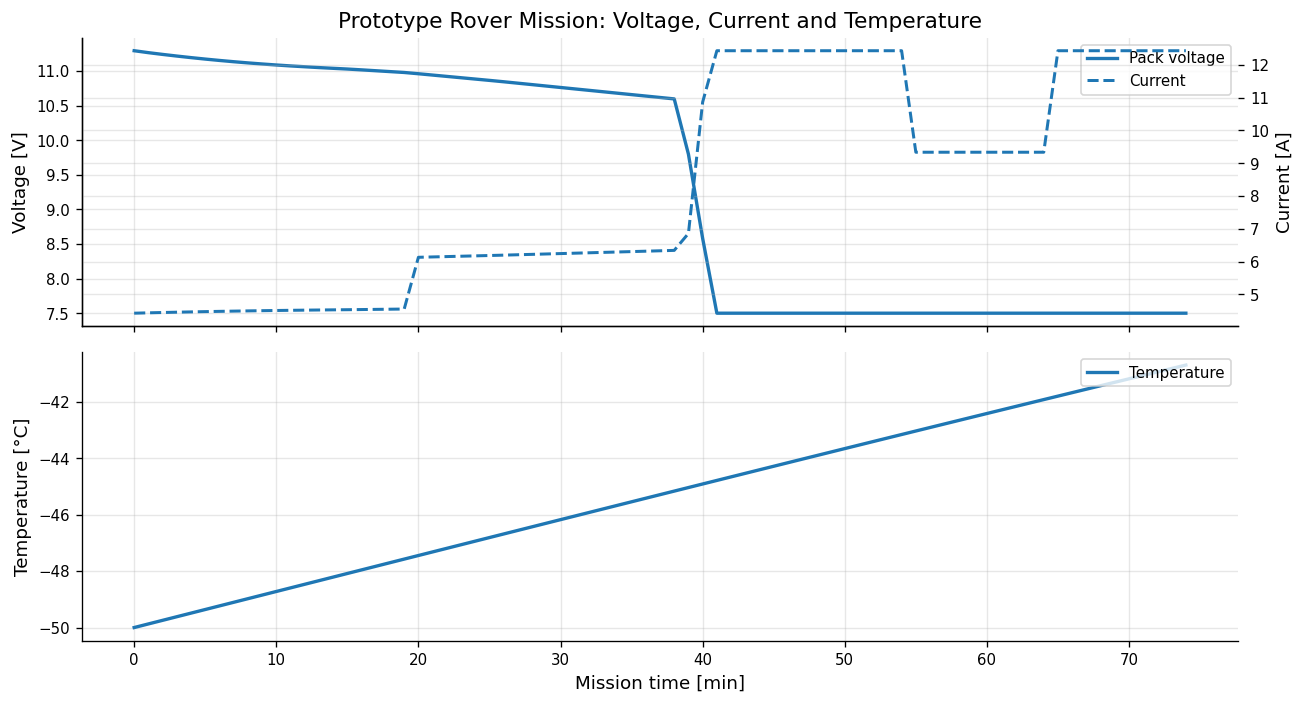

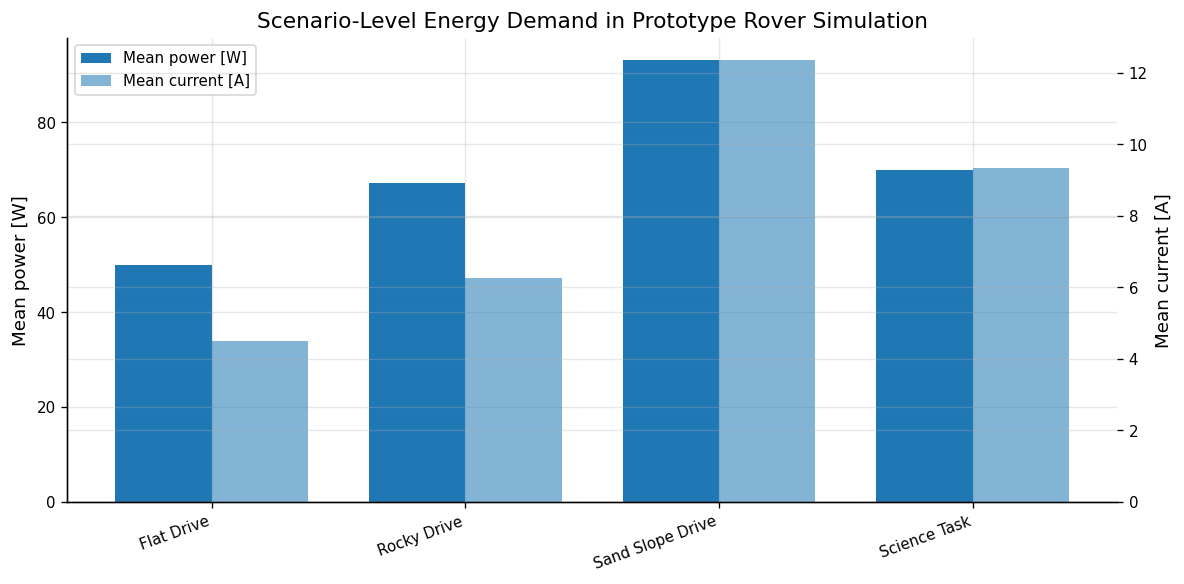

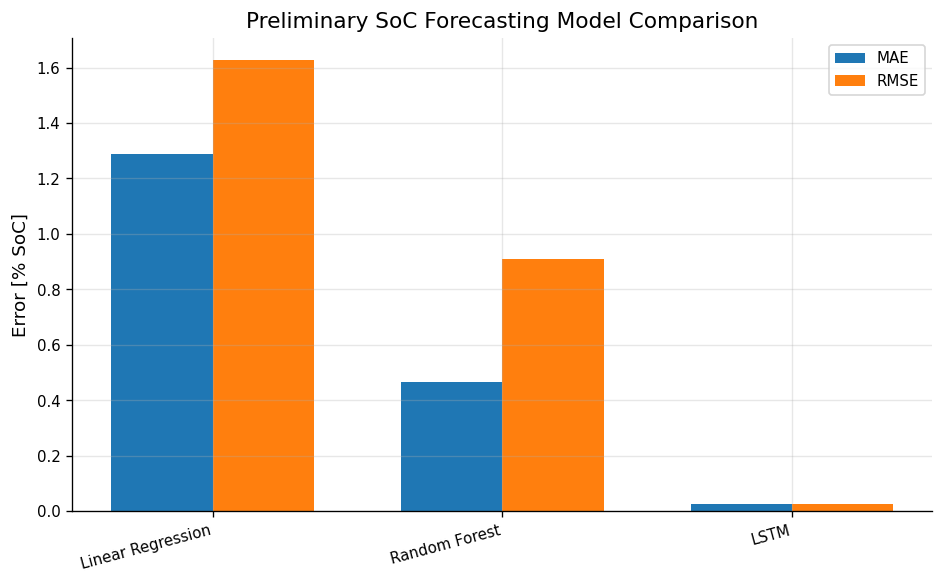

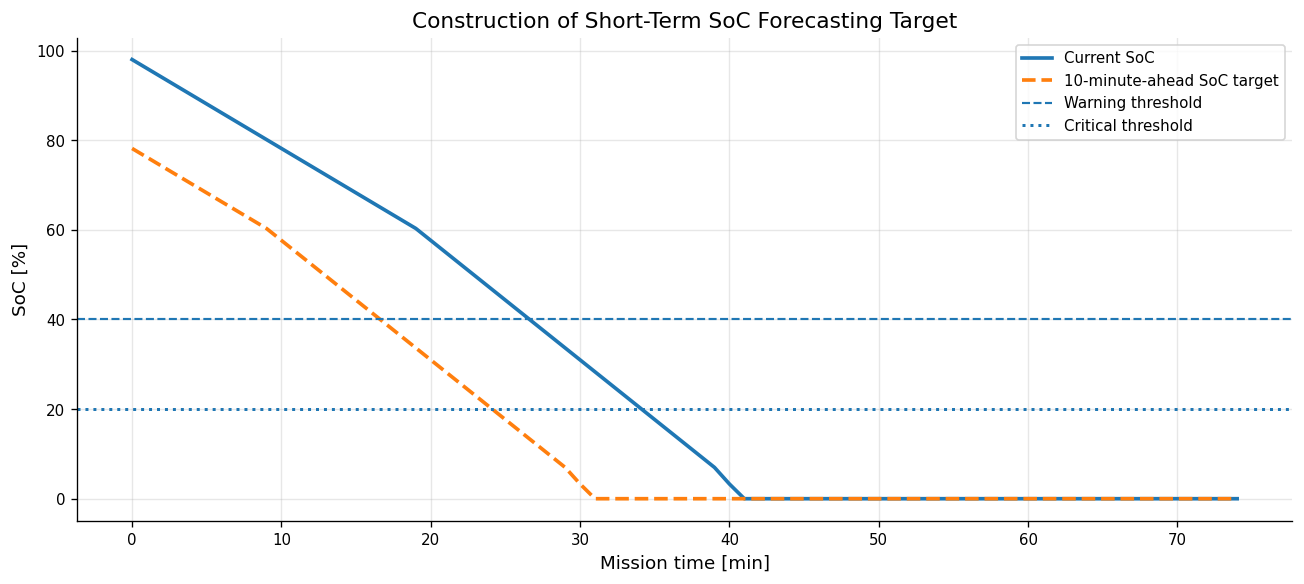


Notebook run complete.

Saved datasets:
data/pybamm_discharge_test.csv
data/mars_rover_mission_telemetry_clean.csv

Saved tables:
results/table_1_prototype_summary.csv
results/table_2_scenario_summary.csv
results/table_3_model_results.csv

Saved figures:
figures/figure_1a_soc_power_demand.png
figures/figure_1b_voltage_current_temperature.png
figures/figure_2_scenario_energy_demand.png
figures/figure_3_model_comparison.png
figures/figure_4_soc_forecasting_target.png


In [2]:
!pip install pybamm matplotlib pandas numpy scikit-learn tensorflow -q


# 1. Imports and Setup

from pathlib import Path

import pybamm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping


# Reproducibility
np.random.seed(42)

# Output folders
DATA_DIR = Path("data")
FIG_DIR = Path("figures")
RESULTS_DIR = Path("results")

DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# Plot style
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.30,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# 2. Project Configuration

config = {
    "battery": {
        "chemistry": "Li-ion",
        "nominal_voltage_v": 12,
        "capacity_ah": 5,
        "capacity_wh": 60,
        "cells_in_series": 3,
        "initial_soc": 100
    },
    "rover": {
        "base_power_w": 10,
        "motor_power_w": 40
    },
    "risk": {
        "warning_soc": 40,
        "critical_soc": 20
    },
    "ml": {
        "forecast_horizon": 10
    }
}


# 3. PyBaMM Battery Discharge Simulation

print("Running PyBaMM lithium-ion battery discharge simulation...")

# Single Particle Model
model = pybamm.lithium_ion.SPM()

# 1C discharge experiment
experiment = pybamm.Experiment([
    "Discharge at 1C until 2.5 V"
])

# Run simulation
sim = pybamm.Simulation(model, experiment=experiment)
solution = sim.solve()

# Extract PyBaMM outputs
time_min = solution["Time [s]"].entries / 60
cell_voltage_v = solution["Terminal voltage [V]"].entries
discharge_capacity_ah = solution["Discharge capacity [A.h]"].entries

capacity_max = discharge_capacity_ah.max()
estimated_soc_percent = 100 * (1 - discharge_capacity_ah / capacity_max)

pybamm_df = pd.DataFrame({
    "time_min": time_min,
    "cell_voltage_v": cell_voltage_v,
    "discharge_capacity_ah": discharge_capacity_ah,
    "estimated_soc_percent": estimated_soc_percent
})

pybamm_df.to_csv(DATA_DIR / "pybamm_discharge_test.csv", index=False)

display(pybamm_df.head())


# 4. Voltage Lookup from PyBaMM Output

def get_voltage_from_soc(soc):
    """
    Approximate single-cell voltage from SoC using PyBaMM discharge output.
    """
    soc = np.clip(soc, 0, 100)


    soc_lookup = pybamm_df["estimated_soc_percent"].values[::-1]
    voltage_lookup = pybamm_df["cell_voltage_v"].values[::-1]

    return np.interp(soc, soc_lookup, voltage_lookup)


def get_pack_voltage_from_soc(soc):
    """
    Convert PyBaMM single-cell voltage to approximate pack voltage.
    """
    cell_voltage = get_voltage_from_soc(soc)
    pack_voltage = cell_voltage * config["battery"]["cells_in_series"]
    return pack_voltage


print("Voltage lookup check:")
print("Cell voltage at 100% SoC:", round(get_voltage_from_soc(100), 3), "V")
print("Cell voltage at 50% SoC:", round(get_voltage_from_soc(50), 3), "V")
print("Cell voltage at 0% SoC:", round(get_voltage_from_soc(0), 3), "V")


# 5. Rover Mission Simulation Helper Functions

def calculate_power_demand(
    terrain_factor=1.0,
    slope_factor=1.0,
    payload_power_w=0
):
    """
    Calculates rover power demand using base power, motor load,
    terrain factor, slope factor, and payload power.
    """
    base_power_w = config["rover"]["base_power_w"]
    motor_power_w = config["rover"]["motor_power_w"]

    total_power = base_power_w + (motor_power_w * terrain_factor * slope_factor) + payload_power_w
    return total_power


def temperature_capacity_factor(temp_c):
    """
    Simple capacity reduction factor for cold operating conditions.
    """
    if temp_c < -40:
        return 0.70
    elif temp_c < -20:
        return 0.85
    elif temp_c < 0:
        return 0.93
    else:
        return 1.00


def mars_temperature(time_min):
    """
    Simplified Mars-like temperature cycle.
    This is not a full climate model; it is used only for prototype simulation.
    """
    sol_minutes = 24.6 * 60
    mean_temp_c = -50
    amplitude_c = 30

    temperature_c = mean_temp_c + amplitude_c * np.sin(2 * np.pi * time_min / sol_minutes)
    return temperature_c


def assign_risk_label(soc):
    """
    Assign low-energy risk state from SoC thresholds.
    """
    if soc < config["risk"]["critical_soc"]:
        return "critical"
    elif soc < config["risk"]["warning_soc"]:
        return "warning"
    else:
        return "safe"


# Scenario definitions
mars_scenarios = {
    "flat_drive": {
        "terrain_factor": 1.0,
        "slope_factor": 1.0,
        "payload_power_w": 0
    },
    "rocky_drive": {
        "terrain_factor": 1.3,
        "slope_factor": 1.1,
        "payload_power_w": 0
    },
    "sand_slope_drive": {
        "terrain_factor": 1.6,
        "slope_factor": 1.3,
        "payload_power_w": 0
    },
    "science_task": {
        "terrain_factor": 1.0,
        "slope_factor": 1.0,
        "payload_power_w": 20
    }
}

print("\nScenario power demands:")
for scenario_name, scenario_params in mars_scenarios.items():
    power = calculate_power_demand(**scenario_params)
    print(f"{scenario_name}: {power:.1f} W")


# 6. Generate Prototype Rover Mission Telemetry

mission_plan = [
    {"duration_min": 20, "scenario": "flat_drive"},
    {"duration_min": 20, "scenario": "rocky_drive"},
    {"duration_min": 15, "scenario": "sand_slope_drive"},
    {"duration_min": 10, "scenario": "science_task"},
    {"duration_min": 20, "scenario": "sand_slope_drive"},
]

rows = []
time_counter = 0
soc = config["battery"]["initial_soc"]

for segment in mission_plan:
    scenario_name = segment["scenario"]
    duration = segment["duration_min"]
    scenario_params = mars_scenarios[scenario_name]

    for _ in range(duration):
        temperature_c = mars_temperature(time_counter)
        capacity_factor = temperature_capacity_factor(temperature_c)

        effective_capacity_wh = config["battery"]["capacity_wh"] * capacity_factor

        power_w = calculate_power_demand(**scenario_params)
        energy_used_wh = power_w / 60

        soc_drop = (energy_used_wh / effective_capacity_wh) * 100
        soc = max(0, soc - soc_drop)

        pack_voltage_v = get_pack_voltage_from_soc(soc)
        current_a = power_w / pack_voltage_v if pack_voltage_v > 0 else np.nan

        rows.append({
            "time_min": time_counter,
            "scenario": scenario_name,
            "temperature_c": temperature_c,
            "capacity_factor": capacity_factor,
            "effective_capacity_wh": effective_capacity_wh,
            "power_w": power_w,
            "energy_used_wh": energy_used_wh,
            "soc_percent": soc,
            "pack_voltage_v": pack_voltage_v,
            "current_a": current_a,
            "risk_label": assign_risk_label(soc)
        })

        time_counter += 1

mission_df = pd.DataFrame(rows)

# Create 10-minute-ahead SoC forecasting target
forecast_horizon = config["ml"]["forecast_horizon"]
mission_df["soc_future_10"] = mission_df["soc_percent"].shift(-forecast_horizon)

# Remove rows where future target is unavailable
mission_df = mission_df.dropna().reset_index(drop=True)

mission_df.to_csv(DATA_DIR / "mars_rover_mission_telemetry_clean.csv", index=False)

print("\nMission telemetry created.")
print("Mission dataframe shape:", mission_df.shape)
print("\nRisk label counts:")
print(mission_df["risk_label"].value_counts())

display(mission_df.head())


# 7. Summary Tables

# Table 1: Prototype configuration summary
prototype_summary = pd.DataFrame({
    "Item": [
        "Battery chemistry",
        "Nominal voltage",
        "Battery capacity",
        "Forecast horizon",
        "Warning threshold",
        "Critical threshold",
        "Telemetry interval",
        "Usable rows",
        "Number of variables"
    ],
    "Value": [
        config["battery"]["chemistry"],
        f"{config['battery']['nominal_voltage_v']} V",
        f"{config['battery']['capacity_ah']} Ah / {config['battery']['capacity_wh']} Wh",
        f"{config['ml']['forecast_horizon']} minutes",
        f"{config['risk']['warning_soc']}% SoC",
        f"{config['risk']['critical_soc']}% SoC",
        "1 minute",
        len(mission_df),
        mission_df.shape[1]
    ]
})

prototype_summary.to_csv(RESULTS_DIR / "table_1_prototype_summary.csv", index=False)

print("\nTable 1: Prototype dataset and configuration summary")
display(prototype_summary)


# Table 2: Scenario-level summary
scenario_summary = (
    mission_df
    .groupby("scenario")
    .agg(
        mean_power_w=("power_w", "mean"),
        mean_current_a=("current_a", "mean"),
        mean_voltage_v=("pack_voltage_v", "mean"),
        final_soc_percent=("soc_percent", "min"),
        samples=("time_min", "count")
    )
    .reset_index()
)

scenario_summary["scenario_clean"] = (
    scenario_summary["scenario"]
    .str.replace("_", " ")
    .str.title()
)

scenario_summary_report = scenario_summary[
    [
        "scenario_clean",
        "mean_power_w",
        "mean_current_a",
        "mean_voltage_v",
        "final_soc_percent",
        "samples"
    ]
].rename(columns={
    "scenario_clean": "Scenario",
    "mean_power_w": "Mean Power (W)",
    "mean_current_a": "Mean Current (A)",
    "mean_voltage_v": "Mean Voltage (V)",
    "final_soc_percent": "Final SoC (%)",
    "samples": "Samples"
})

scenario_summary_report = scenario_summary_report.round(2)
scenario_summary_report.to_csv(RESULTS_DIR / "table_2_scenario_summary.csv", index=False)

print("\nTable 2: Scenario-level energy demand summary")
display(scenario_summary_report)


# 8. Preliminary Machine Learning Proof of Concept

features = [
    "time_min",
    "temperature_c",
    "power_w",
    "soc_percent",
    "pack_voltage_v",
    "current_a"
]

target = "soc_future_10"

X = mission_df[features]
y = mission_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Linear Regression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)


# Random Forest

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)


# Simple LSTM Trial

df_lstm = mission_df.sort_values("time_min").reset_index(drop=True)

X_lstm_raw = df_lstm[features].values
y_lstm_raw = df_lstm[target].values

scaler = MinMaxScaler()
X_lstm_scaled = scaler.fit_transform(X_lstm_raw)

sequence_length = 5

X_seq = []
y_seq = []

for i in range(len(X_lstm_scaled) - sequence_length):
    X_seq.append(X_lstm_scaled[i:i + sequence_length])
    y_seq.append(y_lstm_raw[i + sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

split_index = int(len(X_seq) * 0.8)

X_train_lstm = X_seq[:split_index]
X_test_lstm = X_seq[split_index:]

y_train_lstm = y_seq[:split_index]
y_test_lstm = y_seq[split_index:]

lstm_model = Sequential([
    LSTM(32, input_shape=(sequence_length, len(features))),
    Dense(16, activation="relu"),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_split=0.2,
    epochs=40,
    batch_size=8,
    callbacks=[early_stop],
    verbose=0
)

lstm_pred = lstm_model.predict(X_test_lstm, verbose=0).flatten()

lstm_mae = mean_absolute_error(y_test_lstm, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_lstm, lstm_pred))
lstm_r2 = r2_score(y_test_lstm, lstm_pred)


# Table 3: Model comparison
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "LSTM"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        lstm_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        lstm_rmse
    ],
    "R2": [
        lr_r2,
        rf_r2,
        lstm_r2
    ],
    "Status": [
        "Prototype tested",
        "Prototype tested",
        "Initial trial"
    ]
})

model_results[["MAE", "RMSE", "R2"]] = model_results[["MAE", "RMSE", "R2"]].round(3)

model_results.to_csv(RESULTS_DIR / "table_3_model_results.csv", index=False)

print("\nTable 3: Preliminary model comparison")
display(model_results)


# Figures

df_report = mission_df.copy().sort_values("time_min").reset_index(drop=True)


# Figure 1(a): SoC and Power Demand

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(
    df_report["time_min"],
    df_report["soc_percent"],
    linewidth=2.2,
    label="State of Charge"
)

axes[0].axhline(
    config["risk"]["warning_soc"],
    linestyle="--",
    linewidth=1.5,
    label="Warning threshold"
)

axes[0].axhline(
    config["risk"]["critical_soc"],
    linestyle=":",
    linewidth=1.8,
    label="Critical threshold"
)

axes[0].set_ylabel("SoC [%]")
axes[0].set_title("Prototype Rover Mission: SoC and Power Demand")
axes[0].legend(loc="upper right")

axes[1].plot(
    df_report["time_min"],
    df_report["power_w"],
    linewidth=2.0,
    label="Power demand"
)

axes[1].set_ylabel("Power [W]")
axes[1].set_xlabel("Mission time [min]")
axes[1].legend(loc="upper right")

# Scenario labels on SoC plot
scenario_blocks = df_report["scenario"].ne(df_report["scenario"].shift()).cumsum()

for _, block in df_report.groupby(scenario_blocks):
    start = block["time_min"].min()
    end = block["time_min"].max()
    label = block["scenario"].iloc[0].replace("_", " ").title()
    mid = (start + end) / 2

    axes[0].axvspan(start, end, alpha=0.08)
    axes[0].text(
        mid,
        102,
        label,
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.savefig(FIG_DIR / "figure_1a_soc_power_demand.png", bbox_inches="tight")
plt.show()


# Figure 1(b): Voltage, Current and Temperature

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(
    df_report["time_min"],
    df_report["pack_voltage_v"],
    linewidth=2.0,
    label="Pack voltage"
)

axes[0].set_ylabel("Voltage [V]")

ax_current = axes[0].twinx()

ax_current.plot(
    df_report["time_min"],
    df_report["current_a"],
    linewidth=1.8,
    linestyle="--",
    label="Current"
)

ax_current.set_ylabel("Current [A]")

lines_1, labels_1 = axes[0].get_legend_handles_labels()
lines_2, labels_2 = ax_current.get_legend_handles_labels()

axes[0].legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper right"
)

axes[0].set_title("Prototype Rover Mission: Voltage, Current and Temperature")

axes[1].plot(
    df_report["time_min"],
    df_report["temperature_c"],
    linewidth=2.0,
    label="Temperature"
)

axes[1].set_ylabel("Temperature [°C]")
axes[1].set_xlabel("Mission time [min]")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig(FIG_DIR / "figure_1b_voltage_current_temperature.png", bbox_inches="tight")
plt.show()


# Figure 2: Scenario-Level Energy Demand

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(scenario_summary))
width = 0.38

ax.bar(
    x - width / 2,
    scenario_summary["mean_power_w"],
    width,
    label="Mean power [W]"
)

ax2 = ax.twinx()

ax2.bar(
    x + width / 2,
    scenario_summary["mean_current_a"],
    width,
    alpha=0.55,
    label="Mean current [A]"
)

ax.set_xticks(x)
ax.set_xticklabels(
    scenario_summary["scenario_clean"],
    rotation=20,
    ha="right"
)

ax.set_ylabel("Mean power [W]")
ax2.set_ylabel("Mean current [A]")
ax.set_title("Scenario-Level Energy Demand in Prototype Rover Simulation")

lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left"
)

plt.tight_layout()
plt.savefig(FIG_DIR / "figure_2_scenario_energy_demand.png", bbox_inches="tight")
plt.show()


# Figure 3: Preliminary Model Comparison

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(model_results))
width = 0.35

ax.bar(
    x - width / 2,
    model_results["MAE"],
    width,
    label="MAE"
)

ax.bar(
    x + width / 2,
    model_results["RMSE"],
    width,
    label="RMSE"
)

ax.set_xticks(x)
ax.set_xticklabels(
    model_results["Model"],
    rotation=15,
    ha="right"
)

ax.set_ylabel("Error [% SoC]")
ax.set_title("Preliminary SoC Forecasting Model Comparison")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "figure_3_model_comparison.png", bbox_inches="tight")
plt.show()


# Figure 4: Short-Term SoC Forecasting Target

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    df_report["time_min"],
    df_report["soc_percent"],
    linewidth=2.2,
    label="Current SoC"
)

ax.plot(
    df_report["time_min"],
    df_report["soc_future_10"],
    linewidth=2.2,
    linestyle="--",
    label="10-minute-ahead SoC target"
)

ax.axhline(
    config["risk"]["warning_soc"],
    linestyle="--",
    linewidth=1.3,
    label="Warning threshold"
)

ax.axhline(
    config["risk"]["critical_soc"],
    linestyle=":",
    linewidth=1.8,
    label="Critical threshold"
)

ax.set_xlabel("Mission time [min]")
ax.set_ylabel("SoC [%]")
ax.set_title("Construction of Short-Term SoC Forecasting Target")
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig(FIG_DIR / "figure_4_soc_forecasting_target.png", bbox_inches="tight")
plt.show()


# Output Summary

print("\nNotebook run complete.")
print("\nSaved datasets:")
print(DATA_DIR / "pybamm_discharge_test.csv")
print(DATA_DIR / "mars_rover_mission_telemetry_clean.csv")

print("\nSaved tables:")
print(RESULTS_DIR / "table_1_prototype_summary.csv")
print(RESULTS_DIR / "table_2_scenario_summary.csv")
print(RESULTS_DIR / "table_3_model_results.csv")

print("\nSaved figures:")
print(FIG_DIR / "figure_1a_soc_power_demand.png")
print(FIG_DIR / "figure_1b_voltage_current_temperature.png")
print(FIG_DIR / "figure_2_scenario_energy_demand.png")
print(FIG_DIR / "figure_3_model_comparison.png")
print(FIG_DIR / "figure_4_soc_forecasting_target.png")